# Bluesky User Posts — EDA

## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Imports

In [2]:
import tarfile
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Dataset Path

In [3]:
TAR_PATH   = "/content/drive/MyDrive/bluesky_dataset/user_posts.tar.gz" # Change to whatever shortcut you saved your path at (lmk if thius works)
SAVE_PATH  = "/content/drive/MyDrive/bluesky_dataset/posts_sample.csv"
SAMPLE_SIZE = 100_000

## 4. Sampling Posts

In [4]:
# inspect a single post to see available fields
with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        line = f.readline()
        post = json.loads(line)
        print("Keys:", list(post.keys()))
        print("\nFull post:")
        print(json.dumps(post, indent=2))
        break

Keys: ['post_id', 'user_id', 'instance', 'date', 'text', 'langs', 'like_count', 'reply_count', 'repost_count', 'reply_to', 'replied_author', 'thread_root', 'thread_root_author', 'repost_from', 'reposted_author', 'quotes', 'quoted_author', 'labels', 'sent_label', 'sent_score']

Full post:
{
  "post_id": 128238232,
  "user_id": 1662063,
  "instance": "bsky.social",
  "date": 202403101740,
  "text": "\u306a\u3093\u3067\u305d\u3093\u306a\u306b\u4ed6\u4eba\u3092\u30b3\u30f3\u30c8\u30ed\u30fc\u30eb\u3057\u305f\u304c\u308b\u3093\u3067\u3057\u3087\u3046\u306d\u3047",
  "langs": [
    "jpn"
  ],
  "like_count": 0,
  "reply_count": 0,
  "repost_count": 0,
  "reply_to": null,
  "replied_author": null,
  "thread_root": null,
  "thread_root_author": null,
  "repost_from": null,
  "reposted_author": null,
  "quotes": null,
  "quoted_author": null,
  "labels": null,
  "sent_label": null,
  "sent_score": null
}


Scanned 2,000,000 posts



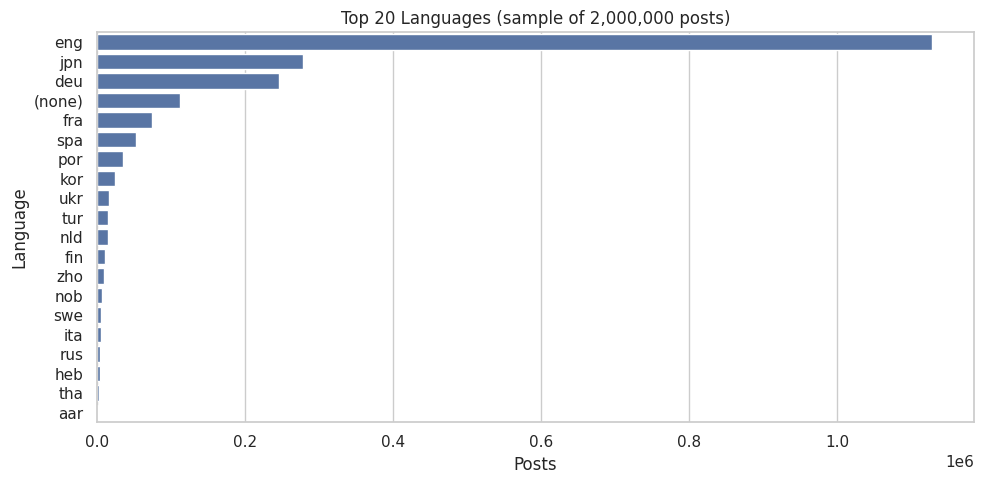

In [21]:
from collections import Counter

lang_counts = Counter()
posts_scanned = 0
MAX_SCAN = 2000_000

with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if posts_scanned >= MAX_SCAN:
            break
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        for line in f:
            if posts_scanned >= MAX_SCAN:
                break
            try:
                post = json.loads(line)
                langs = post.get("langs")
                if not langs:
                    lang_counts["(none)"] += 1
                else:
                    for l in langs:
                        lang_counts[l] += 1
                posts_scanned += 1
            except json.JSONDecodeError:
                continue

print(f"Scanned {posts_scanned:,} posts\n")
lang_df = pd.DataFrame(lang_counts.most_common(20), columns=["lang", "count"])
lang_df["pct"] = (lang_df["count"] / posts_scanned * 100).round(1)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lang_df, x="count", y="lang", ax=ax)
ax.set(title=f"Top 20 Languages (sample of {posts_scanned:,} posts)", xlabel="Posts", ylabel="Language")
plt.tight_layout()
plt.show()

In [22]:

'''
Currently cause we are streaming from the tar we have to go front first and all the first lot of users are non-english hence why it takes so long (around a minute)
(maybe early adopter to platform or just how theyve structured it). A TODO is to preprocess this data properly by extracting the tar
getting out the 100GB of raw data optimising how we store it instead of json and then well be able to accesss repeatedly and do a true random sampling
with much more flexibility.
'''
import time

records = []
t0 = time.time()

with tarfile.open(TAR_PATH, "r|gz") as tar:
    for member in tar:
        if len(records) >= SAMPLE_SIZE:
            break
        if not member.name.endswith(".jsonl"):
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        for line in f:
            try:
                post = json.loads(line)
                langs = post.get("langs")
                if langs and "eng" not in langs:
                    break  # skip if non-english user
                records.append({
                    "post_id":      post.get("post_id"),
                    "user_id":      post.get("user_id"),
                    "text":         post.get("text"),
                    "date":         post.get("date"),
                    "like_count":   post.get("like_count"),
                    "reply_count":  post.get("reply_count"),
                    "repost_count": post.get("repost_count"),
                    "is_reply":     post.get("reply_to") is not None,
                    "is_repost":    post.get("repost_from") is not None,
                    "is_quote":     post.get("quotes") is not None,
                })
                break  #getting just one post per user can adapt accordingly (each jsonl represnt all the posts of a user)
            except json.JSONDecodeError:
                continue

print(f"Done. {len(records):,} posts in {time.time()-t0:.1f}s")

Done. 100,000 posts in 68.2s


## 5. Convert to DataFrame

In [17]:
df = pd.DataFrame(records)

#date format is YYYYMMDDHHmm
df["timestamp"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d%H%M", errors="coerce")
df["text_length"] = df["text"].str.len()

df.head()

,post_id,user_id,text,date,like_count,reply_count,repost_count,is_reply,is_repost,is_quote,timestamp,text_length
0,185310363,1028680,Listening to some good talks at BSides Canberra,202309280146,0,0,0,False,False,False,2023-09-28 01:46:00,47
1,91191550,265900,Are you an elementary educator who teaches kid...,202311091238,6,0,3,False,True,False,2023-11-09 12:38:00,292
2,95619644,3174300,,202307271950,4,1,0,False,False,False,2023-07-27 19:50:00,0
3,161062409,1535259,They're just fascists that like Bayes' Theorem.,202309072338,3,0,0,False,False,False,2023-09-07 23:38:00,47
4,219348642,706124,the democrats do not like the idea of a chines...,202403132118,24,1,8,False,True,False,2024-03-13 21:18:00,166


## 6. Dataset Inspection

In [18]:
print("Shape:", df.shape)
df.info()

Shape: (100000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   post_id       100000 non-null  int64         
 1   user_id       100000 non-null  int64         
 2   text          100000 non-null  object        
 3   date          100000 non-null  int64         
 4   like_count    100000 non-null  int64         
 5   reply_count   100000 non-null  int64         
 6   repost_count  100000 non-null  int64         
 7   is_reply      100000 non-null  bool          
 8   is_repost     100000 non-null  bool          
 9   is_quote      100000 non-null  bool          
 10  timestamp     100000 non-null  datetime64[ns]
 11  text_length   100000 non-null  int64         
dtypes: bool(3), datetime64[ns](1), int64(7), object(1)
memory usage: 7.2+ MB


count    100000.000000
mean         89.969070
std          85.208947
min           0.000000
25%          24.000000
50%          59.000000
75%         133.000000
max         423.000000
Name: text_length, dtype: float64


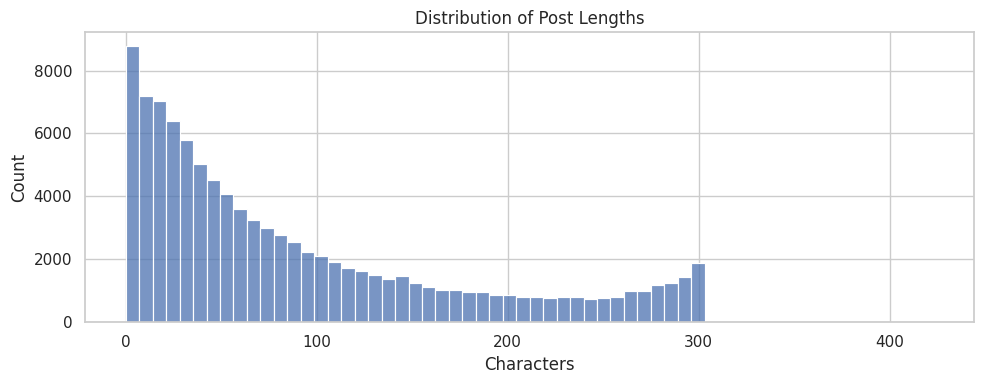

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["text_length"].dropna(), bins=60, ax=ax)
ax.set(title="Distribution of Post Lengths", xlabel="Characters", ylabel="Count")
plt.tight_layout()
plt.show()

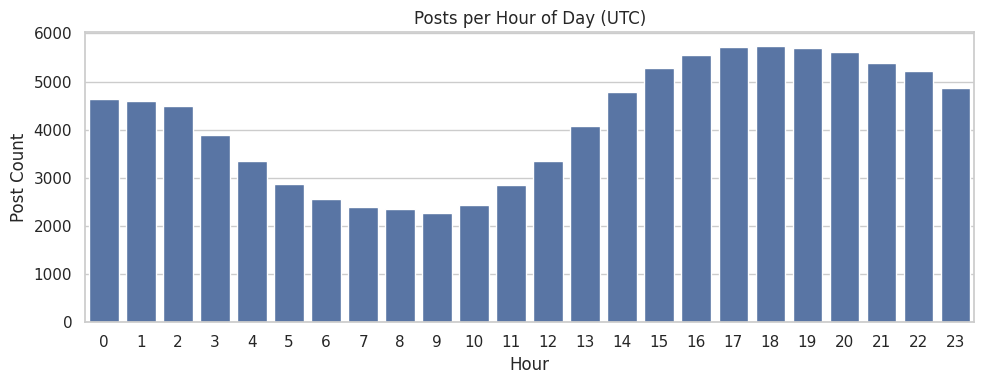

In [20]:

df["hour"] = df["timestamp"].dt.hour
posts_per_hour = df.groupby("hour").size().reindex(range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=posts_per_hour.index, y=posts_per_hour.values, ax=ax)
ax.set(title="Posts per Hour of Day (UTC)", xlabel="Hour", ylabel="Post Count")
plt.tight_layout()
plt.show()

In [ ]:
#save sample to drive
df.to_csv(SAVE_PATH, index=False)
print(f"Saved {len(df):,} rows to {SAVE_PATH}")